In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score
import xgboost as xgb

from sklearn.model_selection import  RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    log_loss,
    accuracy_score,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
df = pd.read_parquet('../data/match_dataset.parquet')
df['match_date'] = pd.to_datetime(df['match_date'])
df = df.sort_values(by='match_date').reset_index(drop=True)
df

,t1_id,map_stat_id,t1_kills_avg,t1_kills_median,t1_kills_p25,t1_kills_p75,t1_kills_std,t1_clutches_avg,t1_clutches_median,t1_clutches_p25,...,t2_kast_median,t2_kast_p25,t2_kast_p75,t2_kast_std,match_date,winner,map_encoding,event_weight,t1_elo,t2_elo
0,11982,163828,17.2,18.0,16.0,20.0,3.346640,0.4,0.0,0.0,...,133.3,116.6,141.6,15.152063,2023-10-04 13:00:00+00:00,0,0,0.000000,1500.000000,1500.000000
1,11518,163825,14.4,13.0,12.0,17.0,4.669047,0.0,0.0,0.0,...,156.0,138.6,165.1,16.080050,2023-10-04 13:00:00+00:00,1,1,0.000000,1500.000000,1500.000000
2,7969,163823,10.6,10.0,8.0,11.0,3.911521,0.0,0.0,0.0,...,132.1,132.1,146.4,14.170109,2023-10-04 13:00:00+00:00,1,0,0.000000,1500.000000,1500.000000
3,11321,163824,20.0,20.0,16.0,21.0,5.787918,0.2,0.0,0.0,...,150.4,137.1,164.7,19.671223,2023-10-04 13:00:00+00:00,1,0,0.000000,1500.000000,1500.000000
4,11861,163821,13.6,13.0,11.0,13.0,6.308724,0.6,0.0,0.0,...,141.7,125.0,150.0,25.287250,2023-10-04 13:00:00+00:00,0,0,0.000000,1500.000000,1500.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43055,13605,216045,16.0,16.0,15.0,17.0,1.581139,0.4,0.0,0.0,...,126.7,126.7,128.3,8.811356,2025-12-28 05:40:00+00:00,0,3,0.022298,1510.288978,1489.711022
43056,13440,216039,16.2,20.0,12.0,20.0,5.848077,0.0,0.0,0.0,...,120.8,120.8,133.3,17.356180,2025-12-28 06:00:00+00:00,0,8,0.022298,1532.081026,1520.989787
43057,13440,216043,14.6,15.0,13.0,17.0,4.505552,0.2,0.0,0.0,...,118.3,101.7,123.3,32.616989,2025-12-28 06:00:00+00:00,0,5,0.022298,1537.137331,1515.933483
43058,13370,216047,12.8,12.0,9.0,14.0,5.805170,0.4,0.0,0.0,...,126.7,118.3,135.0,33.956929,2025-12-28 06:30:00+00:00,0,4,0.022298,1479.900290,1502.172053


In [3]:
split_date = '2025-11-30'

train_mask = df['match_date'] <= split_date
test_mask = df['match_date'] > split_date

In [4]:
target_col = 'winner'
weight_col = 'event_weight'
cols_to_drop = [target_col, weight_col, 'match_date', 'map_stat_id', 't1_id', 't2_id']

In [5]:
swing_cols = [c for c in df.columns if 'swing' in c]
rating_cols = [c for c in df.columns if 'rating' in c]
df = df.drop(columns=swing_cols)
df = df.drop(columns=rating_cols)

In [6]:
X_train = df.loc[train_mask].drop(columns=cols_to_drop)
y_train = df.loc[train_mask, target_col]
w_train = df.loc[train_mask, weight_col]

In [7]:
X_prod = df.loc[test_mask].drop(columns=cols_to_drop)
y_prod = df.loc[test_mask, target_col]

In [8]:
print(f"Split Date: {split_date}")
print(f"Training Samples (Historical): {len(X_train)}")
print(f"Production Samples (Future):   {len(X_prod)}")

Split Date: 2025-11-30
Training Samples (Historical): 42148
Production Samples (Future):   912


In [9]:
param_dist = {
    'n_estimators': [100, 300, 500, 800, 1000],
    'learning_rate': [0.001, 0.005, 0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.4, 0.5, 0.6],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 4, 5]
}

In [10]:
tscv = TimeSeriesSplit(n_splits=5)

model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

In [11]:
print("\nStarting Random Search on historical data...")
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_log_loss',
    cv=tscv,
    verbose=3,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train, sample_weight=w_train)

best_model = random_search.best_estimator_

print("-" * 30)
print(f"Best Params: {random_search.best_params_}")
print("-" * 30)


Starting Random Search on historical data...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END colsample_bytree=0.5, gamma=0.2, learning_rate=0.03, max_depth=8, min_child_weight=3, n_estimators=500, reg_alpha=1, reg_lambda=1, subsample=0.8;, score=-0.686 total time=   0.9s
[CV 1/5] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=7, n_estimators=1000, reg_alpha=0.1, reg_lambda=5, subsample=0.8;, score=-0.686 total time=   1.5s
[CV 2/5] END colsample_bytree=0.5, gamma=0.2, learning_rate=0.03, max_depth=8, min_child_weight=3, n_estimators=500, reg_alpha=1, reg_lambda=1, subsample=0.8;, score=-0.475 total time=   2.3s
[CV 1/5] END colsample_bytree=0.6, gamma=0, learning_rate=0.001, max_depth=6, min_child_weight=1, n_estimators=1000, reg_alpha=1, reg_lambda=2, subsample=0.7;, score=-0.686 total time=   1.6s
[CV 2/5] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=7, n_estimators=1000, reg_alp

In [12]:
if len(X_prod) > 0:
    preds_proba = best_model.predict_proba(X_prod)[:, 1]
    preds_class = best_model.predict(X_prod)

    prod_log_loss = log_loss(y_prod, preds_proba)
    prod_acc = accuracy_score(y_prod, preds_class)

    print(f"RESULTS ON DATA AFTER {split_date}:")
    print(f"Log Loss: {prod_log_loss:.4f}")
    print(f"Accuracy: {prod_acc:.2%}")
else:
    print("No data found after 2025-11-30 to test.")

RESULTS ON DATA AFTER 2025-11-30:
Log Loss: 0.4412
Accuracy: 82.02%


/var/folders/rp/lcxnvlln3qq7ym11pq6qf0w00000gn/T/ipykernel_90937/1014086459.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], ax=axes[2, 0], palette='viridis')


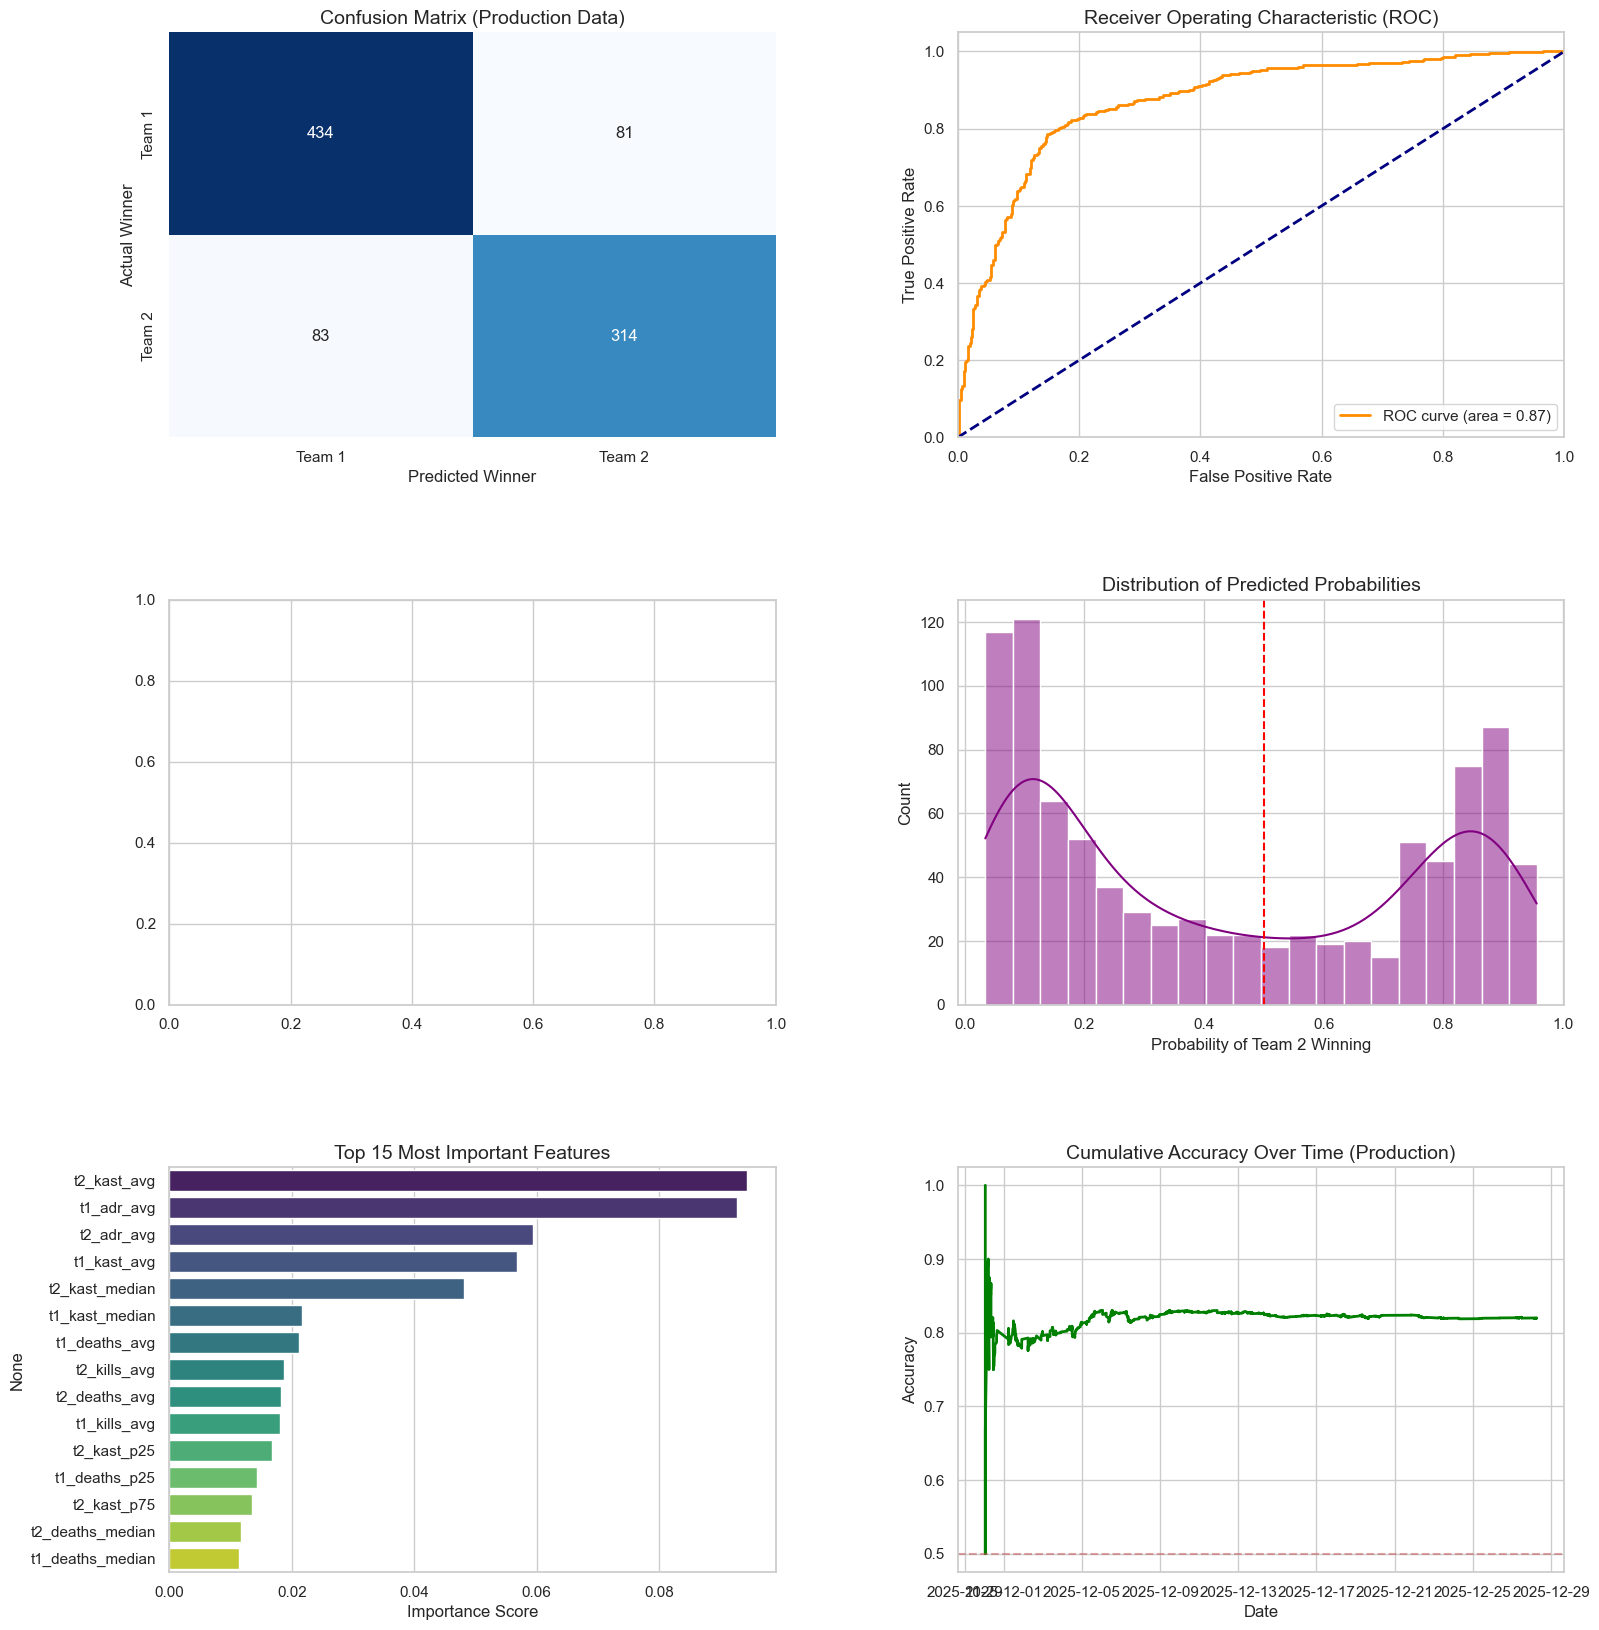

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# Set the style for professional looking plots
sns.set_theme(style="whitegrid")

# Create a figure with subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ---------------------------------------------------------
# PLOT 1: Confusion Matrix
# ---------------------------------------------------------
# Shows where the model is making mistakes (False Positives vs False Negatives)
cm = confusion_matrix(y_prod, preds_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Confusion Matrix (Production Data)', fontsize=14)
axes[0, 0].set_xlabel('Predicted Winner')
axes[0, 0].set_ylabel('Actual Winner')
axes[0, 0].set_xticklabels(['Team 1', 'Team 2'])
axes[0, 0].set_yticklabels(['Team 1', 'Team 2'])

# ---------------------------------------------------------
# PLOT 2: ROC Curve
# ---------------------------------------------------------
# Measures how well the model separates winners from losers
fpr, tpr, thresholds = roc_curve(y_prod, preds_proba)
roc_auc = auc(fpr, tpr)

axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
axes[0, 1].legend(loc="lower right")

# ---------------------------------------------------------
# PLOT 4: Probability Distribution
# ---------------------------------------------------------
# Shows how "sure" the model usually is. 
# You want peaks near 0 and 1, and few predictions near 0.5.
sns.histplot(preds_proba, bins=20, kde=True, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Predicted Probabilities', fontsize=14)
axes[1, 1].set_xlabel('Probability of Team 2 Winning')
axes[1, 1].axvline(0.5, color='red', linestyle='--')

# ---------------------------------------------------------
# PLOT 5: Feature Importance (Top 15)
# ---------------------------------------------------------
# What stats is the model actually looking at?
# Note: XGBoost usually provides 'weight', 'gain', or 'cover'. 'Gain' is best.
importances = best_model.feature_importances_
feature_names = X_prod.columns
# Sort indices
indices = np.argsort(importances)[::-1][:15] # Top 15

sns.barplot(x=importances[indices], y=feature_names[indices], ax=axes[2, 0], palette='viridis')
axes[2, 0].set_title('Top 15 Most Important Features', fontsize=14)
axes[2, 0].set_xlabel('Importance Score')

# ---------------------------------------------------------
# PLOT 6: Cumulative Accuracy Over Time
# ---------------------------------------------------------
# Does the model degrade over time? (Data Drift)
# We need to recover the dates for the X_prod data
# Assuming df is available and indices match (or re-merge on index)
dates_prod = df.loc[X_prod.index, 'match_date']
correct_preds = (preds_class == y_prod).astype(int)

# Create a temporary DF for plotting
perf_df = pd.DataFrame({'date': dates_prod, 'correct': correct_preds})
perf_df = perf_df.sort_values('date')
perf_df['cumulative_accuracy'] = perf_df['correct'].expanding().mean()

axes[2, 1].plot(perf_df['date'], perf_df['cumulative_accuracy'], color='green', lw=2)
axes[2, 1].set_title('Cumulative Accuracy Over Time (Production)', fontsize=14)
axes[2, 1].set_xlabel('Date')
axes[2, 1].set_ylabel('Accuracy')
axes[2, 1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5) # Random guess line

plt.show()

/Users/erikbayerlein/Documents/clutch-or-predict/.venv/lib/python3.12/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


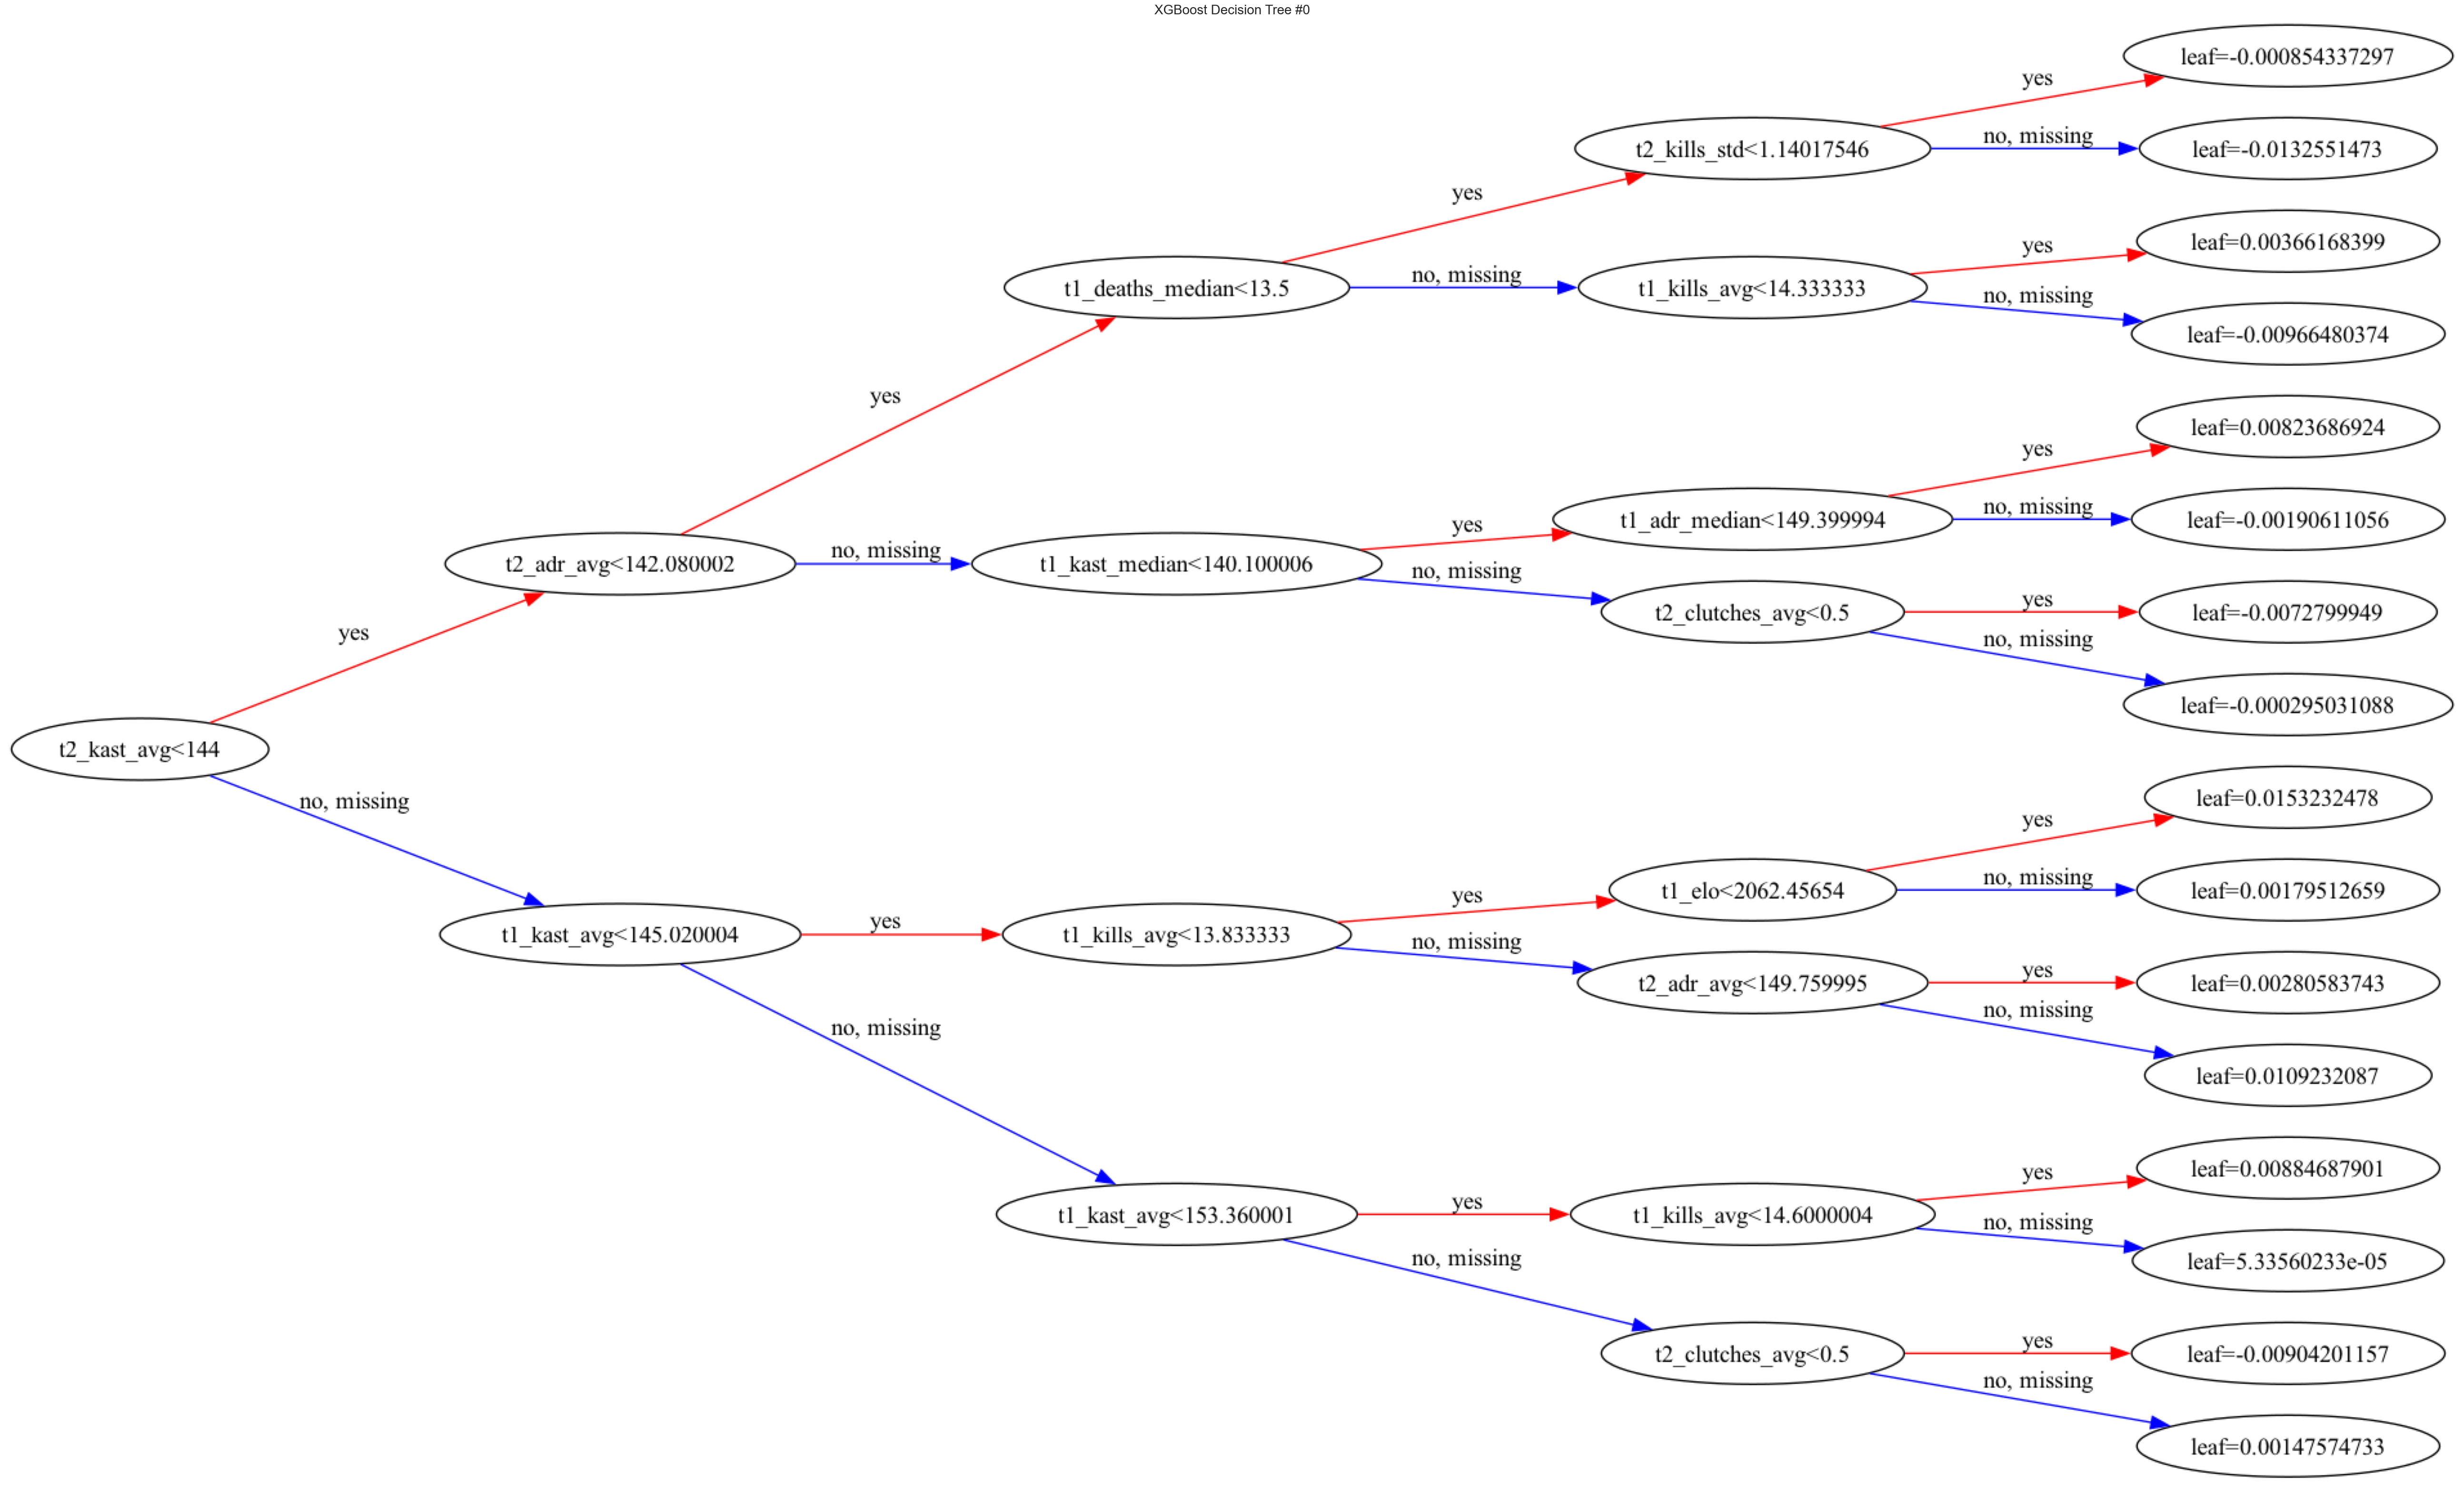

In [14]:
# 1. SETUP PLOT SIZE
# Trees can be very wide. We set a massive figure size to make text readable.
plt.rcParams['figure.figsize'] = [80, 40]  # Width, Height in inches

# 2. PLOT THE FIRST TREE
# best_model: Your trained XGBClassifier
# num_trees=0: The very first tree in the ensemble (usually the most general rules)
# rankdir='LR': Left-to-Right orientation (often easier to read than Top-Down)
xgb.plot_tree(best_model, num_trees=0, rankdir='LR')

# 3. SHOW
plt.title("XGBoost Decision Tree #0", fontsize=20)
plt.show()